<a href="https://colab.research.google.com/github/samarreguigui/summarization/blob/main/verbosity_bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Verbosity Bias — FineSurE on one paper

Tests whether FineSurE rewards summary length over content quality, using your human-written summaries.

## 1. Setup — install deps & clone FineSurE

In [23]:
!pip install -q --upgrade "openai>=1.55.0" httpx
!git clone -q https://github.com/DISL-Lab/FineSurE-ACL24.git
import nltk; nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
import sys; sys.path.insert(0, '/content/FineSurE-ACL24/finesure')
print('Setup done.')

fatal: destination path 'FineSurE-ACL24' already exists and is not an empty directory.
Setup done.


## 2. Mount Google Drive

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Configuration

Adjust paths to point at your project folder in Drive. Everything else can stay as default for the first run.

In [25]:
from pathlib import Path

# --- Paths in Drive (change PROJECT to your project folder if needed) ---
PROJECT     = Path('/content/drive/MyDrive/summarization')
PAPER_DIR   = PROJECT / 'data' / 'paper'
SUMMARY_DIR = PROJECT / 'data' / 'different summaries size'
KEY_FILE    = Path('/content/drive/MyDrive/Master thesis/openrouter_key.txt')
# --- Output / cache directories (local to this Colab session; copied to Drive at the end) ---
WORK_DIR      = Path('/content/work')
CACHE_DIR     = WORK_DIR / 'cache'         # one JSON per API call, keyed by prompt hash
RESULTS_DIR   = WORK_DIR / 'results'       # scores.csv and figures
ARTICLES_DIR  = WORK_DIR / 'articles'      # cleaned article text
KEYFACTS_DIR  = WORK_DIR / 'keyfacts'      # frozen keyfact list per paper
for d in [WORK_DIR, CACHE_DIR, RESULTS_DIR, ARTICLES_DIR, KEYFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Which paper to process ---
PAPER_ID  = '02'

# --- Model & API ---
# OpenRouter exposes OpenAI-compatible endpoints. Same model as FineSurE script default.
MODEL          = 'openai/gpt-4o-2024-05-13' # same as DISL-Lab/FineSurE-ACL24 default
# Alternatives (uncomment one to match the paper exactly):
# MODEL = 'openai/gpt-4-1106-preview'       # the model in the FineSurE paper
# MODEL = 'openai/gpt-3.5-turbo-0125'
OPENROUTER_URL = 'https://openrouter.ai/api/v1'
TEMPERATURE    = 0.0                        # FineSurE uses 0.0

print('Project root:', PROJECT)
print('Paper ID    :', PAPER_ID)
print('Model       :', MODEL)

Project root: /content/drive/MyDrive/summarization
Paper ID    : 02
Model       : openai/gpt-4o-2024-05-13


## 4. Helpers — PDF → text, sentence split, token count

In [26]:
import fitz, re, hashlib, json, os, time
from typing import List
import tiktoken
from nltk.tokenize import sent_tokenize

ENC = tiktoken.get_encoding('cl100k_base')

def n_tokens(text: str) -> int:
    return len(ENC.encode(text))

def read_pdf(path: Path) -> str:
    '''Extract text from a PDF file using PyMuPDF.'''
    doc = fitz.open(path)
    text = '\n'.join(page.get_text() for page in doc)
    doc.close()
    return text

def clean_article(raw: str) -> str:
    '''Light cleaning: strip everything from References section onward, collapse whitespace.'''
    cut = re.split(r'\n\s*(References|REFERENCES|Bibliography)\b', raw, maxsplit=1)[0]
    cut = re.sub(r'[ \t]+', ' ', cut)
    cut = re.sub(r'\n{3,}', '\n\n', cut)
    return cut.strip()

def clean_summary(raw: str) -> str:
    '''Summaries are short; just normalise whitespace.'''
    return re.sub(r'\s+', ' ', raw).strip()

def sentences_of(text: str) -> List[str]:
    return [s.strip() for s in sent_tokenize(text) if s.strip()]

print('Helpers ready.')

Helpers ready.


## 5. OpenRouter client + cached call

Every call's prompt is hashed; the response is saved to `cache/<hash>.json`.
Re-running the notebook reads cached responses and does **not** re-hit the API.

In [36]:
import openai

API_KEY = KEY_FILE.read_text().strip()
client = openai.OpenAI(api_key=API_KEY, base_url=OPENROUTER_URL)

def _cache_key(model: str, prompt: str, temperature: float) -> str:
    h = hashlib.sha256()
    h.update(model.encode()); h.update(b'|')
    h.update(str(temperature).encode()); h.update(b'|')
    h.update(prompt.encode())
    return h.hexdigest()[:24]

def get_response(prompt: str, model: str = None, temperature: float = None, max_retries: int = 3) -> str:
    '''Cached single-turn call. Returns the assistant message content.'''
    model = model or MODEL
    temperature = TEMPERATURE if temperature is None else temperature
    key = _cache_key(model, prompt, temperature)
    cache_file = CACHE_DIR / f'{key}.json'
    if cache_file.exists():
        return json.loads(cache_file.read_text())['response']
    last_err = None
    for attempt in range(max_retries):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{'role': 'user', 'content': prompt}],
                temperature=temperature,
            )
            text = r.choices[0].message.content
            cache_file.write_text(json.dumps({
                'model': model, 'temperature': temperature,
                'prompt': prompt, 'response': text,
            }))
            return text
        except Exception as e:
            last_err = e
            time.sleep(2 ** attempt)
    raise RuntimeError(f'Failed after {max_retries} retries: {last_err}')

print(f'OpenRouter client ready. Cache dir: {CACHE_DIR}')

OpenRouter client ready. Cache dir: /content/work/cache


## 6. Load the source article and its size-variant summaries

In [37]:
def find_article(paper_id: str) -> Path:
    matches = sorted(PAPER_DIR.glob(f'{paper_id}_*.pdf'))
    assert matches, f'No article PDF for paper {paper_id} in {PAPER_DIR}'
    return matches[0]

def find_summaries(paper_id: str):
    '''Return list of (size_label, sub_label, path). Detects short/medium/long/verylong from filename.'''
    items = []
    for p in sorted(SUMMARY_DIR.glob(f'{paper_id}_*.pdf')):
        name = p.stem.lower()
        for size in ['verylong', 'long', 'medium', 'short']:
            if size in name:
                items.append((size, p.stem, p))
                break
    return items

article_path = find_article(PAPER_ID)
summary_items = find_summaries(PAPER_ID)

raw_article = read_pdf(article_path)
article = clean_article(raw_article)
article_file = ARTICLES_DIR / f'{PAPER_ID}.txt'
article_file.write_text(article)

print(f'Article: {article_path.name}  ({n_tokens(article):,} tokens cleaned)')
print(f'Summaries found: {len(summary_items)}')
for size, label, path in summary_items:
    text = clean_summary(read_pdf(path))
    print(f'  [{size:>8}] {label}  ({n_tokens(text)} tokens)')

Article: 02_On the Dangers of Stochastic Parrots.pdf  (15,277 tokens cleaned)
Summaries found: 3
  [    long] 02_sum1_long_gen_hum  (1215 tokens)
  [  medium] 02_sum1_medium_gen_hum  (662 tokens)
  [   short] 02_sum1_short  (306 tokens)


## 7. Step A — Extract keyfacts (one frozen list per paper)

The FineSurE repo ships pre-extracted keyfacts only for FRANK/REALSumm. For new articles we run an extraction prompt that follows the style described in the FineSurE paper (Song et al. 2024, §3). Same model, same temperature.

Keyfact list is cached to `keyfacts/<paper_id>.json` and reused by every summary of this paper.

In [38]:
import ast

KEYFACT_PROMPT = '''
You will receive a transcript. Your task is to extract a list of key facts from the transcript.

A key fact is a short, atomic, factual statement that captures a single piece of important information stated in the transcript. Each key fact should be a complete, standalone sentence.

Instruction:
First, read the transcript carefully.
Second, identify between 10 and 16 distinct key facts that together capture the most important content of the transcript.
Third, write each key fact as a short standalone sentence in plain English.

Provide your answer in JSON format. The answer should be a list of dictionaries whose key is "key fact":
[{"key fact": "first key fact"}, {"key fact": "second key fact"}, {"key fact": "third key fact"}]

Transcript:
%s
'''

def parse_keyfacts(output: str):
    try:
        start = output.find('['); end = output.rfind(']')
        items = ast.literal_eval(output[start:end+1])
        return [d['key fact'].strip() for d in items if 'key fact' in d]
    except Exception as e:
        print('keyfact parse error:', e)
        return []

keyfact_file = KEYFACTS_DIR / f'{PAPER_ID}.json'
if keyfact_file.exists():
    keyfacts = json.loads(keyfact_file.read_text())['key_facts']
    print(f'Loaded {len(keyfacts)} keyfacts from cache.')
else:
    prompt = KEYFACT_PROMPT % article
    raw = get_response(prompt)
    keyfacts = parse_keyfacts(raw)
    keyfact_file.write_text(json.dumps({'doc_id': PAPER_ID, 'key_facts': keyfacts}, indent=2))
    print(f'Extracted {len(keyfacts)} keyfacts.')

for i, kf in enumerate(keyfacts, 1):
    print(f'  {i:2d}. {kf}')

Loaded 16 keyfacts from cache.
   1. The past three years in NLP have seen the development of increasingly large language models.
   2. BERT, GPT-2/3, and Switch-C are examples of large language models developed recently.
   3. Researchers have extended the state of the art on various tasks using these large language models.
   4. The paper questions whether language models can be too big and explores associated risks.
   5. Environmental and financial costs of large language models should be prioritized.
   6. Large datasets from the Internet can overrepresent hegemonic viewpoints and encode biases.
   7. Documentation and curation of datasets are recommended to mitigate risks.
   8. Large language models do not perform natural language understanding.
   9. Human interlocutors may impute meaning to synthetic text where there is none.
  10. Large language models can pick up and reinforce biases and abusive language patterns.
  11. Synthetic text generated by large language models can l

## 8. Step B — Task 1: Fact-checking → **faithfulness**

Uses FineSurE's exact prompt and parser from `utils.py` (cloned repo). Result cached per summary.

In [42]:
from utils import (
    get_fact_checking_prompt,
    parsing_llm_fact_checking_output,
    compute_faithfulness_percentage_score,
)

fact_results = {}
for size, label, path in summary_items:
    cache_f = RESULTS_DIR / f'task1__{label}.json'
    if cache_f.exists():
        fact_results[label] = json.loads(cache_f.read_text())
        print(f'[cache] {label}  faithfulness={fact_results[label]["faithfulness"]:.2f}')
        continue

    summary_text = clean_summary(read_pdf(path))
    sents = sentences_of(summary_text)
    prompt = get_fact_checking_prompt(input=article, sentences=sents)
    raw = get_response(prompt)
    pred_labels, pred_types = parsing_llm_fact_checking_output(raw)
    if not pred_labels:
        print(f'[WARN] empty parse for {label}; skipping')
        continue
    faithfulness = compute_faithfulness_percentage_score(pred_labels)
    out = {
        'summary_label': label, 'size': size,
        'n_sentences': len(sents),
        'pred_labels': pred_labels, 'pred_types': pred_types,
        'faithfulness': faithfulness, 'raw': raw,
    }
    cache_f.write_text(json.dumps(out, indent=2))
    fact_results[label] = out
    print(f'  {label}  sents={len(sents)}  faithfulness={faithfulness:.2f}')

  02_sum1_long_gen_hum  sents=45  faithfulness=1.00
[cache] 02_sum1_medium_gen_hum  faithfulness=0.91
[cache] 02_sum1_short  faithfulness=1.00


## 9. Step C — Task 2: Keyfact alignment → **completeness & conciseness**

In [43]:
from utils import (
    get_keyfact_alighment_prompt,
    parsing_llm_keyfact_alighment_output,
    compute_completeness_percentage_score,
    compute_conciseness_percentage_score,
)

align_results = {}
for size, label, path in summary_items:
    cache_f = RESULTS_DIR / f'task2__{label}.json'
    if cache_f.exists():
        align_results[label] = json.loads(cache_f.read_text())
        r = align_results[label]
        print(f'[cache] {label}  comp={r["completeness"]:.2f}  conc={r["conciseness"]:.2f}')
        continue

    summary_text = clean_summary(read_pdf(path))
    sents = sentences_of(summary_text)
    prompt = get_keyfact_alighment_prompt(keyfacts=keyfacts, sentences=sents)
    raw = get_response(prompt)
    pred_labels, matched_lines = parsing_llm_keyfact_alighment_output(raw)
    if not pred_labels:
        print(f'[WARN] empty parse for {label}; skipping')
        continue
    completeness = compute_completeness_percentage_score(pred_labels)
    conciseness  = compute_conciseness_percentage_score(matched_lines, len(sents))
    out = {
        'summary_label': label, 'size': size,
        'n_sentences': len(sents),
        'keyfact_labels': pred_labels, 'matched_lines': matched_lines,
        'n_keyfacts': len(keyfacts),
        'n_keyfacts_covered': sum(pred_labels),
        'completeness': completeness, 'conciseness': conciseness,
        'raw': raw,
    }
    cache_f.write_text(json.dumps(out, indent=2))
    align_results[label] = out
    print(f'  {label}  comp={completeness:.2f}  conc={conciseness:.2f}')

  02_sum1_long_gen_hum  comp=0.94  conc=0.44
[cache] 02_sum1_medium_gen_hum  comp=0.81  conc=0.43
[cache] 02_sum1_short  comp=0.75  conc=0.69


## 10. Assemble `scores.csv` for this paper

In [44]:
import pandas as pd

rows = []
for size, label, path in summary_items:
    if label not in fact_results or label not in align_results:
        continue
    f = fact_results[label]; a = align_results[label]
    text = clean_summary(read_pdf(path))
    rows.append({
        'paper_id': PAPER_ID,
        'summary_label': label,
        'size': size,
        'realised_tokens': n_tokens(text),
        'n_sentences': f['n_sentences'],
        'faithfulness': f['faithfulness'],
        'completeness': a['completeness'],
        'conciseness': a['conciseness'],
        'n_keyfacts_total': a['n_keyfacts'],
        'n_keyfacts_covered': a['n_keyfacts_covered'],
    })

df = pd.DataFrame(rows).sort_values('realised_tokens').reset_index(drop=True)
scores_csv = RESULTS_DIR / f'scores_paper_{PAPER_ID}.csv'
df.to_csv(scores_csv, index=False)
print('Saved:', scores_csv)
df

Saved: /content/work/results/scores_paper_02.csv


,paper_id,summary_label,size,realised_tokens,n_sentences,faithfulness,completeness,conciseness,n_keyfacts_total,n_keyfacts_covered
0,02,02_sum1_short,short,306,13,1.000000,0.7500,0.692308,16,12
1,02,02_sum1_medium_gen_hum,medium,662,23,0.913043,0.8125,0.434783,16,13
2,02,02_sum1_long_gen_hum,long,1215,45,1.000000,0.9375,0.444444,16,15


## 11. Quick sanity plots (length vs each score)

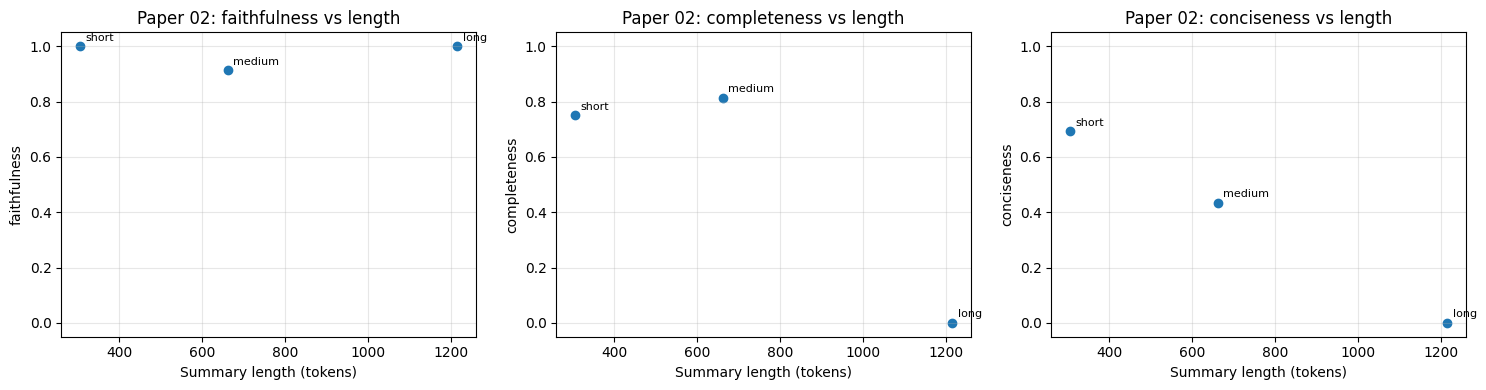

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['faithfulness', 'completeness', 'conciseness']):
    ax.scatter(df['realised_tokens'], df[col])
    for _, r in df.iterrows():
        ax.annotate(r['size'], (r['realised_tokens'], r[col]), fontsize=8,
                    xytext=(4,4), textcoords='offset points')
    ax.set_xlabel('Summary length (tokens)')
    ax.set_ylabel(col)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'Paper {PAPER_ID}: {col} vs length')
    ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / f'plots_paper_{PAPER_ID}.png', dpi=120)
plt.show()

## 12. Save results back to Drive

Copies `work/` (cache + results) into your project so nothing is lost when the Colab runtime resets.

In [34]:
import shutil
dest = PROJECT / 'verbosity_bias_run'
dest.mkdir(parents=True, exist_ok=True)
for sub in ['cache', 'results', 'articles', 'keyfacts']:
    src = WORK_DIR / sub
    out = dest / sub
    if out.exists():
        shutil.rmtree(out)
    shutil.copytree(src, out)
print('Copied results to:', dest)

Copied results to: /content/drive/MyDrive/summarization/verbosity_bias_run


## 13. Next steps

If the table and plots above look sensible:

1. Change `PAPER_ID` in the config cell to `'01'`, `'03'`, `'04'`, `'05'`, `'06'` and re-run cells 6 → 11. Cached calls from this paper are reused; only new API calls hit OpenRouter.
2. After all 6 papers are scored, concatenate every `results/scores_paper_*.csv` into one master `scores.csv` for the cross-paper analysis (Spearman, mixed-effects, random-truncation baseline). Those analyses can live in a separate notebook so this one stays focused on data generation.